# Customer Churn Prediction: анализ и прогноз оттока клиентов

**Цель проекта:** понять, какие факторы связаны с оттоком клиентов телеком-компании, построить модель прогнозирования churn и сформулировать практические рекомендации для удержания клиентов.

**Данные:** публичный датасет IBM Telco Customer Churn (`WA_Fn-UseC_-Telco-Customer-Churn.csv`). В нём 7 043 клиента, демографические признаки, подключенные услуги, тип договора, способ оплаты, ежемесячные платежи, общий чек и целевая переменная `Churn`.

**Бизнес-контекст:** удержание текущего клиента обычно дешевле привлечения нового. Поэтому полезны две вещи: ранний скоринг риска оттока и понятная интерпретация причин, на которые может влиять бизнес.


## Краткие выводы

- В датасете отток составляет **26.5%**: классы умеренно несбалансированы, поэтому одной accuracy недостаточно.
- Самый высокий отток наблюдается у группы клиентов с **month-to-month контрактом**: **42.7%** против **11.3%** у годовых и **2.8%** у двухлетних контрактов.
- Самая рискованная зона жизненного цикла — первые месяцы: у клиентов со стажем **0-6 месяцев** отток около **52.9%**.
- Риск повышается у клиентов с **Fiber optic**, **Electronic check**, **paperless billing**, а также без **OnlineSecurity** и **TechSupport**.
- Лучшая модель **Gradient Boosting**: дает скор по ROC AUC около **0.846** на holdout-выборке. Для retention-задачи дополнительно выбран более мягкий порог, который повышает recall и позволяет находить большую часть клиентов с риском ухода.


## 1. Импорт библиотек и настройки


In [4]:
from pathlib import Path
import os
import sys
import warnings



import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance # библиотека для важности признаков
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", "{:.3f}".format)


## 2. Загрузка данных

Файл `telco_customer_churn.csv` лежит рядом с ноутбуком. Если файла нет, код попробует скачать его из публичного GitHub-зеркала датасета.


In [5]:
DATA_PATH = Path("telco_customer_churn.csv")
DATA_URL = "https://raw.githubusercontent.com/treselle-systems/customer_churn_analysis/master/WA_Fn-UseC_-Telco-Customer-Churn.csv"

if not DATA_PATH.exists():
    pd.read_csv(DATA_URL).to_csv(DATA_PATH, index=False)

raw = pd.read_csv(DATA_PATH)
print(f"Размер датасета: {raw.shape[0]:,} строк и {raw.shape[1]} столбец".replace(",", " "))
raw.head()


Размер датасета: 7 043 строк и 21 столбец


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


## 3. Первичный аудит качества данных

Проверим типы, пропуски, дубликаты и целевую переменную. В датасете `TotalCharges` хранится как строка, потому что у части новых клиентов вместо суммы стоит пробел. Это не настоящие пропуски в поведении клиента: у таких клиентов `tenure = 0`, поэтому общий чек логично заменить на 0.


In [6]:
audit = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "missing_pct": raw.isna().mean() * 100,
    "n_unique": raw.nunique(),
})
print(f"Дубликаты customerID: {raw['customerID'].duplicated().sum()}")
display(audit)


Дубликаты customerID: 0


,dtype,missing,missing_pct,n_unique
customerID,object,0,0.000,7043
gender,object,0,0.000,2
SeniorCitizen,int64,0,0.000,2
Partner,object,0,0.000,2
Dependents,object,0,0.000,2
tenure,int64,0,0.000,73
PhoneService,object,0,0.000,2
MultipleLines,object,0,0.000,3
InternetService,object,0,0.000,3
OnlineSecurity,object,0,0.000,3


In [7]:
df = raw.copy()
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
empty_total_charges = df["TotalCharges"].isna().sum()
print(f"Строк с пустым TotalCharges после преобразования: {empty_total_charges}")
print("tenure у этих клиентов:", sorted(df.loc[df["TotalCharges"].isna(), "tenure"].unique()))

df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["SeniorCitizen"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)
df["IsAutoPayment"] = np.where(
    df["PaymentMethod"].isin(["Bank transfer (automatic)", "Credit card (automatic)"]),
    "Yes",
    "No",
)

df[["tenure", "MonthlyCharges", "TotalCharges", "Churn", "ChurnFlag"]].head()


Строк с пустым TotalCharges после преобразования: 11
tenure у этих клиентов: [np.int64(0)]


,tenure,MonthlyCharges,TotalCharges,Churn,ChurnFlag
0,1,29.850,29.850,No,0
1,34,56.950,1889.500,No,0
2,2,53.850,108.150,Yes,1
3,45,42.300,1840.750,No,0
4,2,70.700,151.650,Yes,1


,Churn,customers,share_pct
0,No,5174,73.463
1,Yes,1869,26.537


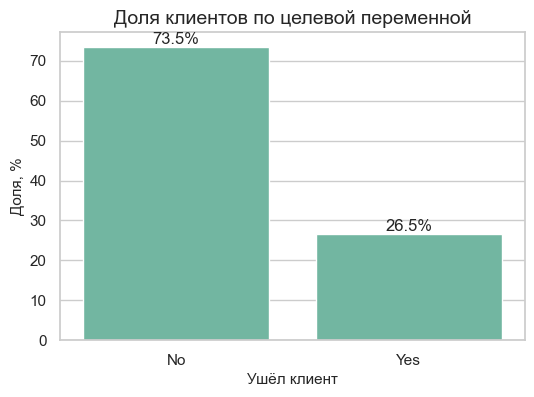

In [8]:
target_summary = (
    df["Churn"]
    .value_counts()
    .rename_axis("Churn")
    .reset_index(name="customers")
)
target_summary["share_pct"] = target_summary["customers"] / len(df) * 100
display(target_summary)

fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(data=target_summary, x="Churn", y="share_pct", ax=ax)
ax.set_title("Доля клиентов по целевой переменной")
ax.set_xlabel("Ушёл клиент")
ax.set_ylabel("Доля, %")
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")
plt.show()


Отток есть примерно у четверти клиентов. В таком случае важнее не просто `accuracy`, а способность ранжировать клиентов по риску (`ROC AUC`, `PR AUC`) и находить достаточную долю будущих уходов (`recall`).


## 4. Exploratory Data Analysis

Сначала посмотрим на числовые признаки. Особенно важен `tenure`: он описывает стаж клиента и часто оказывается сильным индикатором лояльности.


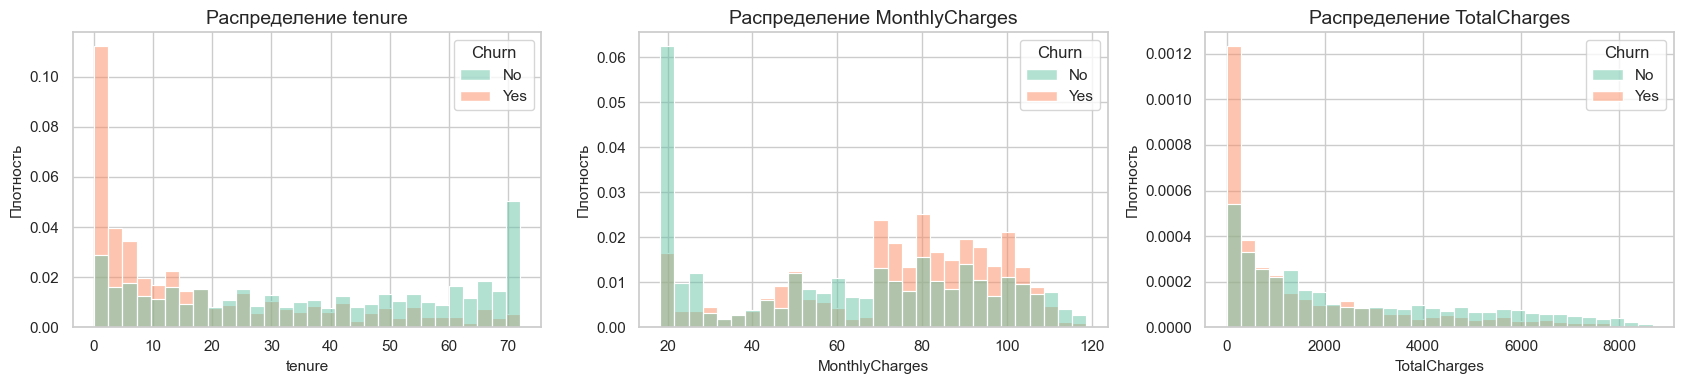

In [9]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, hue="Churn", bins=30, kde=False, stat="density", common_norm=False, ax=ax)
    ax.set_title(f"Распределение {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Плотность")
plt.tight_layout()
plt.show()


### Отток по ключевым сегментам

Функция ниже считает churn rate по категориям. она показывает, где риск концентрируется до построения модели.


In [10]:
def churn_rate_table(data: pd.DataFrame, column: str) -> pd.DataFrame:
    table = (
        data.groupby(column, observed=False)["ChurnFlag"]
        .agg(customers="size", churn_rate="mean")
        .assign(churn_rate_pct=lambda x: x["churn_rate"] * 100)
        .sort_values("churn_rate", ascending=False)
    )
    return table[["customers", "churn_rate_pct"]]

eda_df = df.copy()
eda_df["tenure_group"] = pd.cut(
    eda_df["tenure"],
    bins=[-1, 6, 12, 24, 48, 72],
    labels=["0-6", "7-12", "13-24", "25-48", "49-72"],
)

key_segments = [
    "Contract",
    "tenure_group",
    "InternetService",
    "OnlineSecurity",
    "TechSupport",
    "PaymentMethod",
    "PaperlessBilling",
    "SeniorCitizen",
    "Dependents",
]

for col in key_segments:
    print(f"\n{col}")
    display(churn_rate_table(eda_df, col).round(2))



Contract


,customers,churn_rate_pct
Contract,,
Month-to-month,3875,42.710
One year,1473,11.270
Two year,1695,2.830



tenure_group


,customers,churn_rate_pct
tenure_group,,
0-6,1481,52.940
7-12,705,35.890
13-24,1024,28.710
25-48,1594,20.390
49-72,2239,9.510



InternetService


...

,customers,churn_rate_pct
PaperlessBilling,,
Yes,4171,33.570
No,2872,16.330



SeniorCitizen


,customers,churn_rate_pct
SeniorCitizen,,
Yes,1142,41.680
No,5901,23.610



Dependents


,customers,churn_rate_pct
Dependents,,
No,4933,31.280
Yes,2110,15.450


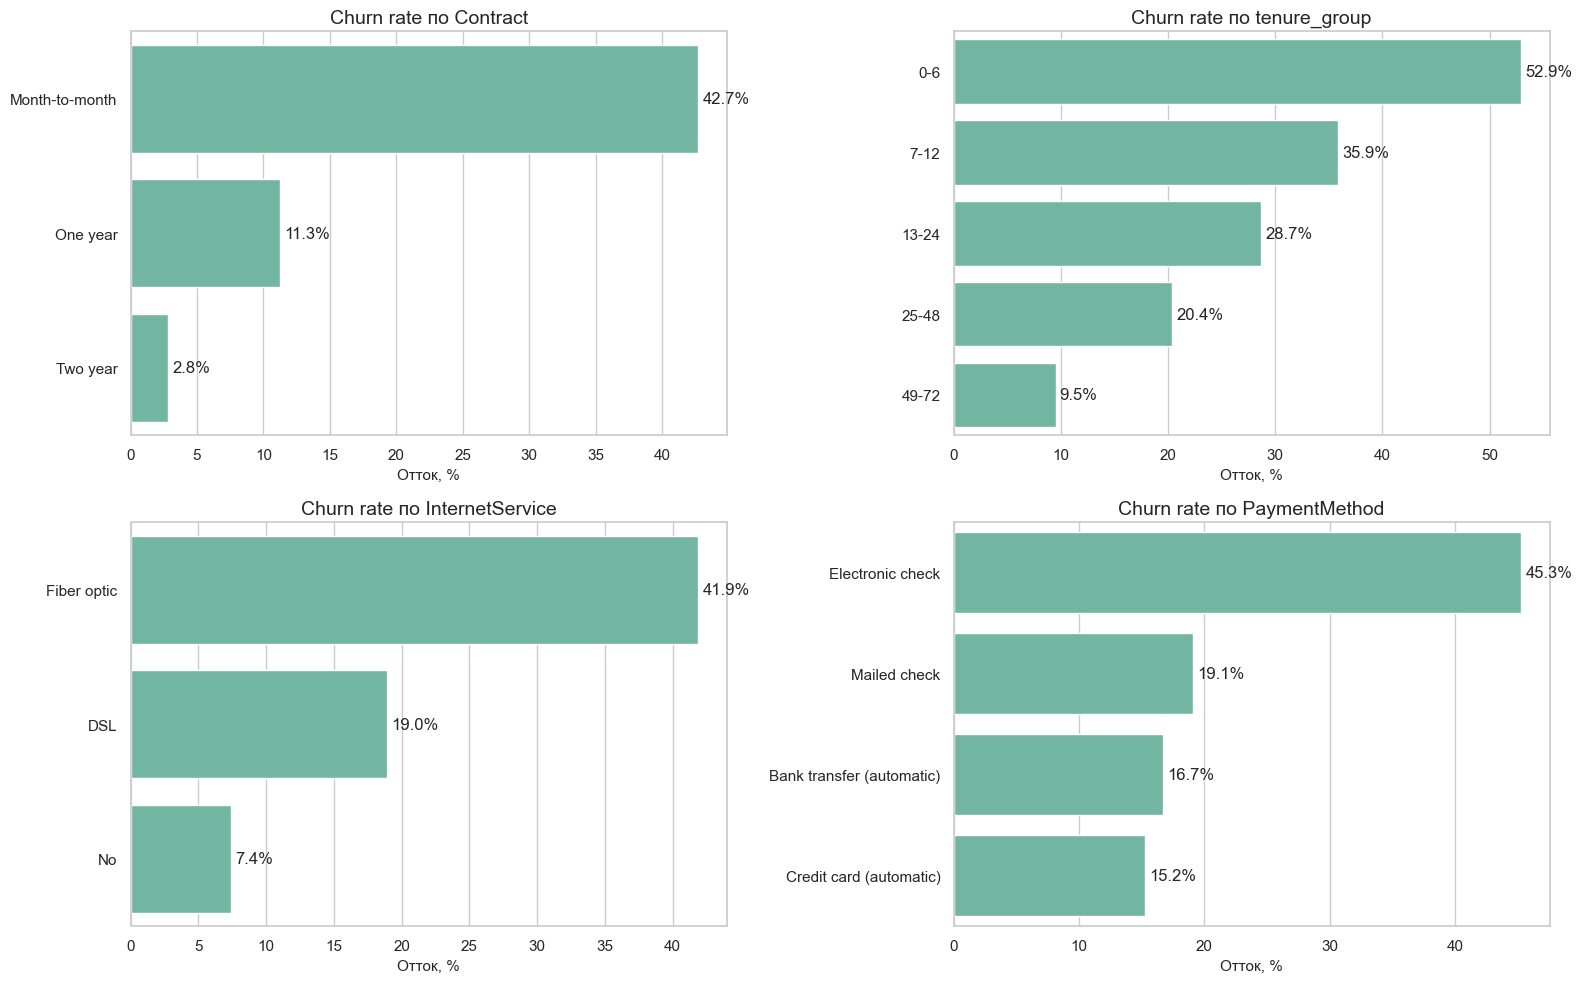

In [11]:
plot_segments = ["Contract", "tenure_group", "InternetService", "PaymentMethod"]
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, col in zip(axes, plot_segments):
    plot_data = churn_rate_table(eda_df, col).reset_index()
    sns.barplot(data=plot_data, y=col, x="churn_rate_pct", ax=ax)
    ax.set_title(f"Churn rate по {col}")
    ax.set_xlabel("Отток, %")
    ax.set_ylabel("")
    for container in ax.containers:
        ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.tight_layout()
plt.show()


### Что видно из EDA

- **Контракт:** клиенты с помесячной оплатой уходят намного чаще. Долгосрочный контракт работает как сильный маркер удержания.
- **Стаж:** первые 6 месяцев — самая опасная зона. Это похоже на проблему онбординга, ожиданий и раннего опыта использования.
- **Интернет-услуги:** у клиентов с Fiber optic churn существенно выше, чем у DSL и клиентов без интернет-сервиса.
- **Поддержка и безопасность:** отсутствие OnlineSecurity и TechSupport связано с заметно более высоким оттоком.
- **Оплата:** Electronic check выглядит рискованнее автоматических способов оплаты. Возможная интерпретация: меньше привычки к автопродлению, больше ручных точек отказа и потенциально другой профиль клиента.


## 5. Подготовка признаков и train/test split

`customerID` не используем как признак: это идентификатор, он не несёт обобщаемого поведения. Целевую переменную кодируем как 1 для `Yes` и 0 для `No`. Разбиение делаем стратифицированным, чтобы сохранить долю churn в train и test.


In [13]:
features = [
    "gender",
    "SeniorCitizen",
    "Partner",
    "Dependents",
    "tenure",
    "PhoneService",
    "MultipleLines",
    "InternetService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies",
    "Contract",
    "PaperlessBilling",
    "PaymentMethod",
    "MonthlyCharges",
    "TotalCharges",
    "IsAutoPayment",
]

target = "ChurnFlag"
numeric_features = ["tenure", "MonthlyCharges", "TotalCharges"]
categorical_features = [col for col in features if col not in numeric_features]

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Доля churn в train:", round(y_train.mean(), 3))
print("Доля churn в test:", round(y_test.mean(), 3))


Train: (5634, 20) Test: (1409, 20)
Доля churn в train: 0.265
Доля churn в test: 0.265


## 6. Моделирование


Основная метрика выбора — `ROC AUC`, потому что она оценивает качество ранжирования клиентов по риску. Дополнительно смотрим `PR AUC`, `precision`, `recall` и `F1`, потому что churn-класс меньше по размеру и бизнесу важна работа именно с уходящими клиентами.


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

logreg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    verbose_feature_names_out=False,
)

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
    ],
    verbose_feature_names_out=False,
)

logreg_grid = GridSearchCV(
    estimator=Pipeline([
        ("preprocess", logreg_preprocessor),
        ("model", LogisticRegression(max_iter=5000, class_weight="balanced", random_state=RANDOM_STATE)),
    ]),
    param_grid={"model__C": [0.03, 0.1, 0.3, 1, 3, 10]},
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
)

gb_grid = GridSearchCV(
    estimator=Pipeline([
        ("preprocess", tree_preprocessor),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE)),
    ]),
    param_grid={
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.03, 0.05, 0.1],
        "model__max_depth": [2, 3],
    },
    scoring="roc_auc",
    cv=cv,
    n_jobs=1,
)

rf_model = Pipeline([
    ("preprocess", tree_preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=15,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=1,
    )),
])


In [15]:
def evaluate_model(name: str, estimator, X_train, X_test, y_train, y_test):
    estimator.fit(X_train, y_train)
    proba = estimator.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return {
        "model": name,
        "ROC AUC": roc_auc_score(y_test, proba),
        "PR AUC": average_precision_score(y_test, proba),
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred),
        "F1": f1_score(y_test, pred),
        "estimator": estimator,
        "proba": proba,
    }

model_results = []
for name, estimator in [
    ("Logistic Regression", logreg_grid),
    ("Gradient Boosting", gb_grid),
    ("Random Forest", rf_model),
]:
    model_results.append(evaluate_model(name, estimator, X_train, X_test, y_train, y_test))

metrics = (
    pd.DataFrame(model_results)
    .drop(columns=["estimator", "proba"])
    .sort_values("ROC AUC", ascending=False)
    .reset_index(drop=True)
)
display(metrics.round(4))

best_row = max(model_results, key=lambda row: row["ROC AUC"])
best_name = best_row["model"]
best_estimator = best_row["estimator"]
best_model = best_estimator.best_estimator_ if hasattr(best_estimator, "best_estimator_") else best_estimator
best_proba = best_row["proba"]

print(f"Лучшая модель по ROC AUC: {best_name}")
if hasattr(best_estimator, "best_params_"):
    print("Лучшие параметры:", best_estimator.best_params_)


,model,ROC AUC,PR AUC,Accuracy,Precision,Recall,F1
0,Gradient Boosting,0.846,0.662,0.801,0.662,0.508,0.575
1,Random Forest,0.842,0.646,0.754,0.524,0.786,0.629
2,Logistic Regression,0.841,0.627,0.737,0.503,0.783,0.613


Лучшая модель по ROC AUC: Gradient Boosting
Лучшие параметры: {'model__learning_rate': 0.05, 'model__max_depth': 2, 'model__n_estimators': 200}


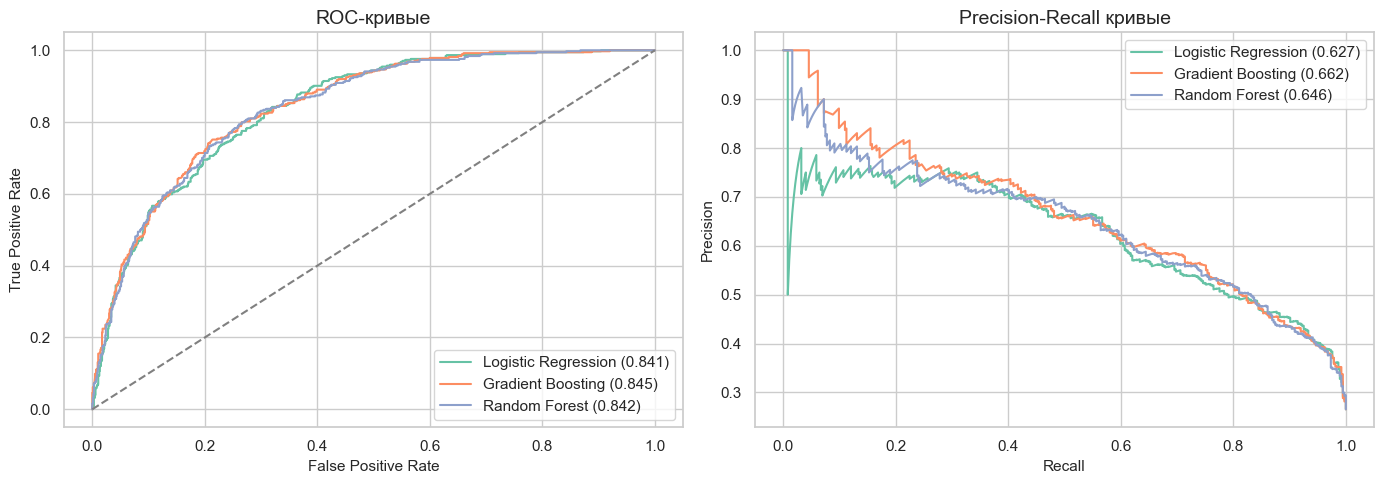

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for result in model_results:
    fpr, tpr, _ = roc_curve(y_test, result["proba"])
    axes[0].plot(fpr, tpr, label=f"{result['model']} ({result['ROC AUC']:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
axes[0].set_title("ROC-кривые")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend()

for result in model_results:
    precision, recall, _ = precision_recall_curve(y_test, result["proba"])
    axes[1].plot(recall, precision, label=f"{result['model']} ({result['PR AUC']:.3f})")
axes[1].set_title("Precision-Recall кривые")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend()

plt.tight_layout()
plt.show()


## 7. Выбор порога для retention-сценария

Стандартный порог 0.5 не всегда подходит для оттока. Если бизнес запускает недорогую retention-кампанию, выгоднее найти больше потенциальных уходов, даже если часть клиентов окажется false positive.


,scenario,threshold,Accuracy,Precision,Recall,F1
0,Стандартный порог,0.500,0.801,0.662,0.508,0.575
1,Retention-порог,0.128,0.657,0.432,0.920,0.588


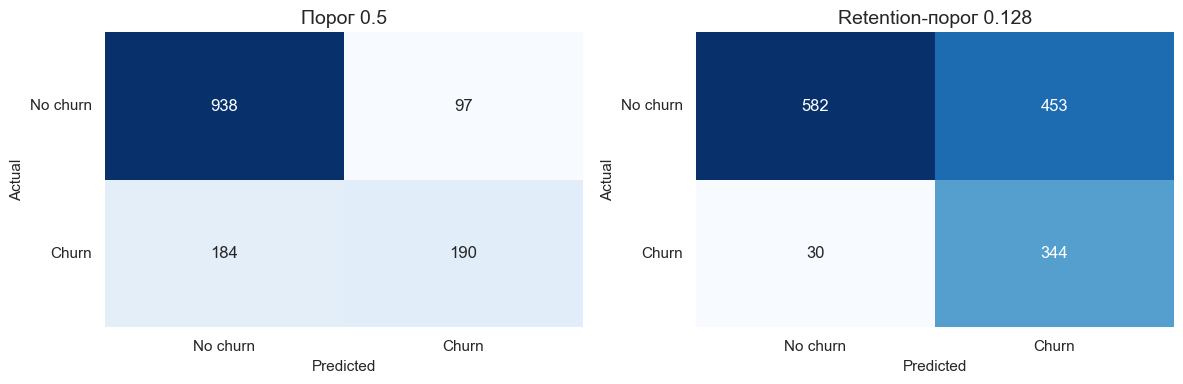

In [21]:
def metrics_at_threshold(y_true, proba, threshold):
    pred = (proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Recall": recall_score(y_true, pred),
        "F1": f1_score(y_true, pred),
    }

precision, recall, thresholds = precision_recall_curve(y_test, best_proba)
best_threshold_idx = int(np.nanargmax(f2[:-1]))
best_threshold = float(thresholds[best_threshold_idx])

threshold_report = pd.DataFrame([
    metrics_at_threshold(y_test, best_proba, 0.5),
    metrics_at_threshold(y_test, best_proba, best_threshold),
])
threshold_report["scenario"] = ["Стандартный порог", "Retention-порог"]
threshold_report = threshold_report[["scenario", "threshold", "Accuracy", "Precision", "Recall", "F1"]]
display(threshold_report.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, threshold, title in [
    (axes[0], 0.5, "Порог 0.5"),
    (axes[1], best_threshold, f"Retention-порог {best_threshold:.3f}"),
]:
    cm = confusion_matrix(y_test, (best_proba >= threshold).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(["No churn", "Churn"])
    ax.set_yticklabels(["No churn", "Churn"], rotation=0)
plt.tight_layout()
plt.show()


**Интерпретация порога.** При стандартном пороге модель делает меньше ложных срабатываний, но пропускает заметную часть уходящих клиентов. Retention-порог снижает precision, зато резко повышает recall. На практике порог нужно выбирать через экономику кампании: стоимость контакта, маржинальность клиента, ожидаемый uplift от предложения и допустимую нагрузку на CRM/колл-центр.


## 8. Интерпретация: что влияет на отток

Для интерпретации используем два взгляда:

- **Permutation importance** лучшей модели: показывает, насколько падает ROC AUC, если перемешать конкретный исходный признак.
- **Коэффициенты Logistic Regression:** помогают понять направление влияния, но их нужно читать аккуратно из-за корреляций между признаками, например `tenure`, `TotalCharges`, `MonthlyCharges`, `Contract`.


,feature,importance_mean,importance_std
0,tenure,0.060,0.003
1,Contract,0.048,0.005
2,InternetService,0.013,0.006
3,TechSupport,0.005,0.002
4,OnlineSecurity,0.005,0.001
5,MonthlyCharges,0.004,0.003
6,PaymentMethod,0.003,0.001
7,TotalCharges,0.003,0.001
8,MultipleLines,0.003,0.001
9,PaperlessBilling,0.003,0.001


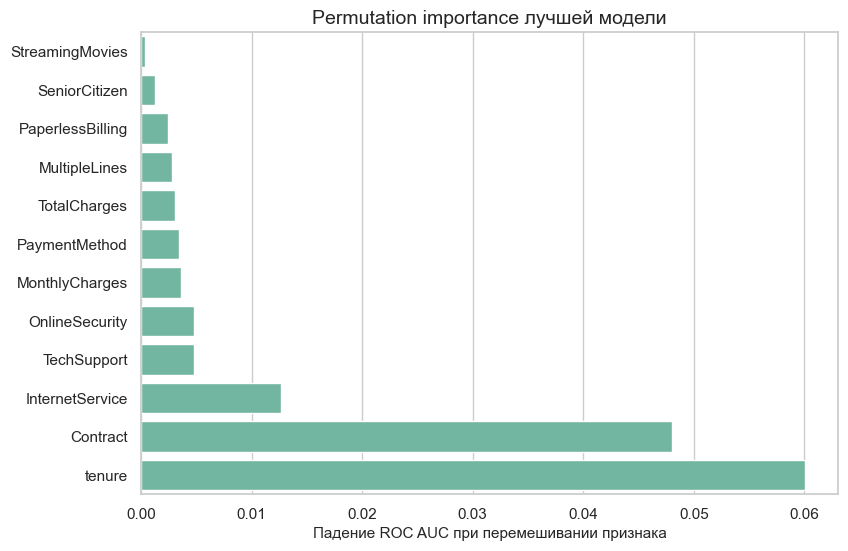

In [22]:
perm = permutation_importance(
    best_model,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=7,
    random_state=RANDOM_STATE,
    n_jobs=1,
)

importance = (
    pd.DataFrame({
        "feature": X_test.columns,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

display(importance.head(12).round(4))

fig, ax = plt.subplots(figsize=(9, 6))
plot_data = importance.head(12).sort_values("importance_mean")
sns.barplot(data=plot_data, x="importance_mean", y="feature", ax=ax)
ax.set_title("Permutation importance лучшей модели")
ax.set_xlabel("Падение ROC AUC при перемешивании признака")
ax.set_ylabel("")
plt.show()


In [23]:
logreg_model = logreg_grid.best_estimator_
feature_names = logreg_model.named_steps["preprocess"].get_feature_names_out()
coefs = logreg_model.named_steps["model"].coef_[0]
coef_table = (
    pd.DataFrame({
        "feature": feature_names,
        "coef": coefs,
    })
    .sort_values("coef", ascending=False)
)

print("Признаки, повышающие вероятность churn по Logistic Regression")
display(coef_table.head(12).round(3))

print("Признаки, снижающие вероятность churn по Logistic Regression")
display(coef_table.tail(12).sort_values("coef").round(3))


Признаки, повышающие вероятность churn по Logistic Regression


,feature,coef
10,InternetService_Fiber optic,2.395
23,StreamingMovies_Yes,0.890
21,StreamingTV_Yes,0.864
9,MultipleLines_Yes,0.561
2,TotalCharges,0.526
26,PaperlessBilling_Yes,0.332
17,DeviceProtection_Yes,0.274
15,OnlineBackup_Yes,0.160
4,SeniorCitizen_Yes,0.155
3,gender_Male,0.032


Признаки, снижающие вероятность churn по Logistic Regression


,feature,coef
1,MonthlyCharges,-1.969
25,Contract_Two year,-1.449
0,tenure,-1.188
8,MultipleLines_No phone service,-0.984
24,Contract_One year,-0.730
30,IsAutoPayment_Yes,-0.549
29,PaymentMethod_Mailed check,-0.500
16,DeviceProtection_No internet service,-0.351
18,TechSupport_No internet service,-0.351
20,StreamingTV_No internet service,-0.351


### Главные факторы оттока

1. **Tenure / стаж клиента.** Самый сильный признак: чем дольше клиент с компанией, тем ниже риск ухода. Новые клиенты требуют отдельного early-life retention процесса.
2. **Тип контракта.** Month-to-month контракты дают клиенту низкий барьер выхода; годовые и двухлетние договоры резко снижают churn.
3. **InternetService и Fiber optic.** Сегмент Fiber optic имеет высокий churn rate.
4. **TechSupport и OnlineSecurity.** Клиенты без поддержки и безопасности уходят чаще. Эти услуги могут работать как элементы ценности и вовлечения.
5. **PaymentMethod.** Electronic check связан с более высоким риском, автоматические платежи — с более низким. Это важная точка для CRM-механик.


## 9. Практические рекомендации

**1. Early-life onboarding для первых 6 месяцев**

- Настроить отдельный мониторинг новых клиентов: 7-й, 30-й, 60-й, 90-й день.
- Проверять удовлетворённость после подключения и первых обращений в поддержку.
- Предлагать помощь с настройкой услуг до того, как клиент столкнётся с проблемой.

**2. Перевод month-to-month клиентов в долгосрочные планы**

- Давать персональные предложения на годовой контракт: скидка, фиксированная цена, бонусная услуга.
- приоритизировать клиентов с высоким predicted churn и высоким ARPU.

**3. Разбор Fiber optic сегмента**

- Сравнить churn по регионам, тарифам, скорости, обращениям в поддержку и жалобам.
- Проверить гипотезы: цена выше ожиданий, нестабильное качество, агрессивные предложения конкурентов.

**4. Бандлы с TechSupport и OnlineSecurity**

- Тестировать бесплатный пробный период или дешёвый bundle для клиентов без этих услуг.

**5. Миграция на автоматические платежи**

- Предлагать небольшой бонус за переход с Electronic check на autopay.

